In [ ]:
# Cell 1 — mount Drive and unzip
from google.colab import drive
drive.mount('/content/drive')
!unzip -q /content/drive/MyDrive/crops-efficientnetb0x224.zip -d /content/
!ls /content/crops-efficientnetb0x224

Mounted at /content/drive
test  train  val


In [ ]:
# Cell 2 — install
!pip install -q timm


In [ ]:
# Cell 3 — run the script
!python train_efficientnet.py

python3: can't open file '/content/train_efficientnet.py': [Errno 2] No such file or directory


# **Primul RUN cu alpha = 1.0**

In [ ]:
best_weights = "/content/drive/MyDrive/EfficientNetB0_acnee/best.pth"

CKPT_PATH = "/content/drive/MyDrive/EfficientNetB0_acnee/best.pth"
ckpt = torch.load(CKPT_PATH, map_location=device)
model = timm.create_model(ckpt.get("arch", "efficientnet_b0"), pretrained=False, num_classes=4)
model.load_state_dict(ckpt["model_state"])
model = model.to(device).eval()


all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds, all_labels = np.array(all_preds), np.array(all_labels)

acc    = accuracy_score(all_labels, all_preds)
f1_mac = f1_score(all_labels, all_preds, average="macro")
f1_w   = f1_score(all_labels, all_preds, average="weighted")

print(f"  Accuracy      : {acc:.4f}")
print(f"  F1 macro      : {f1_mac:.4f}")
print(f"  F1 weighted   : {f1_w:.4f}")
print(f"\n  Classification report:")
print(classification_report(all_labels, all_preds,
                            target_names=test_dataset.classes, digits=4))

  Accuracy      : 0.6914
  F1 macro      : 0.6558
  F1 weighted   : 0.6892

  Classification report:
              precision    recall  f1-score   support

      comedo     0.7879    0.7332    0.7596       922
       nodul     0.7556    0.5690    0.6492       717
      papule     0.6650    0.7921    0.7230      1366
     pustule     0.5038    0.4796    0.4914       417

    accuracy                         0.6914      3422
   macro avg     0.6781    0.6435    0.6558      3422
weighted avg     0.6974    0.6914    0.6892      3422



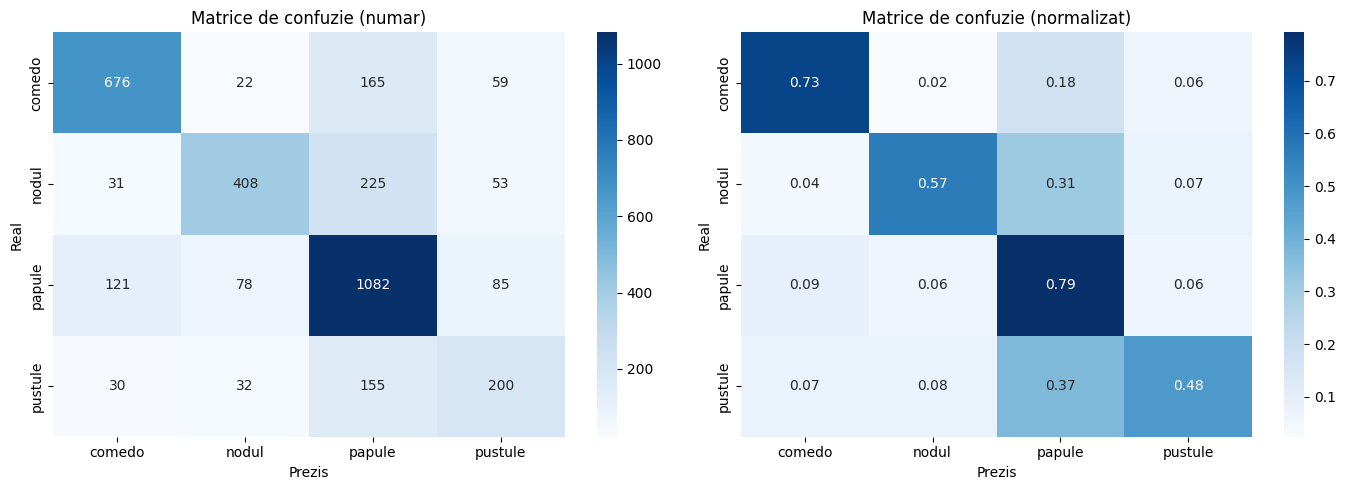

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes, ax=axes[0])
axes[0].set_title("Matrice de confuzie (numar)")
axes[0].set_ylabel("Real"); axes[0].set_xlabel("Prezis")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes, ax=axes[1])
axes[1].set_title("Matrice de confuzie (normalizat)")
axes[1].set_ylabel("Real"); axes[1].set_xlabel("Prezis")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

In [ ]:
import os, json, time, copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
import timm

CROPS_DIR    = "/content/crops-efficientnetb0x224"

ARCH         = "efficientnet_b0"
NUM_CLASSES  = 4
IMG_SIZE     = 224
BATCH_SIZE   = 128
EPOCHS       = 40
LR           = 2e-3
LR_MIN       = 1e-6
WEIGHT_DECAY = 1e-4
PATIENCE     = 8
LABEL_SMOOTH = 0.1

SAVE_DIR = f"/content/drive/MyDrive/EfficientNetB0_acnee_b{BATCH_SIZE}_lr{LR}"

CLASS_NAMES = ["comedo", "nodul", "papule", "pustule"]

Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [ ]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.15, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08)),  # ocluzie partiala
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

In [ ]:
train_dataset = datasets.ImageFolder(os.path.join(CROPS_DIR, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(CROPS_DIR, "val"),   transform=val_transform)
test_dataset  = datasets.ImageFolder(os.path.join(CROPS_DIR, "test"),  transform=val_transform)

print(f"Clase detectate de ImageFolder: {train_dataset.classes}")

# reesantionare ponderata: fiecare batch devine, in asteptare, echilibrat pe clase
class_counts  = Counter(train_dataset.targets)
total_samples = len(train_dataset)
class_weights = {cls: total_samples / count for cls, count in class_counts.items()}
sample_weights = [class_weights[t] for t in train_dataset.targets]
sampler = WeightedRandomSampler(weights=sample_weights,
                                num_samples=len(sample_weights),
                                replacement=True)

print("\nDistributie clase train:")
for cls_idx, cls_name in enumerate(train_dataset.classes):
    print(f"  {cls_name:12s}: {class_counts[cls_idx]:>5}  weight={class_weights[cls_idx]:.3f}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)

print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Clase detectate de ImageFolder: ['comedo', 'nodul', 'papule', 'pustule']

Distributie clase train:
  comedo      :  4904  weight=3.603
  nodul       :  3795  weight=4.656
  papule      :  6868  weight=2.573
  pustule     :  2101  weight=8.409

Train: 17668 | Val: 4495 | Test: 3422


In [ ]:
model = timm.create_model(ARCH, pretrained=True, num_classes=NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model: {ARCH}")
print(f"  Total parametri: {total_params:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model: efficientnet_b0
  Total parametri: 4,012,672


In [ ]:
# label smoothing: reduce supraincrederea, util pt clase vizual similare
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR_MIN)

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, device=device):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            preds          = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_loss    += loss.item() * images.size(0)
            total_samples += images.size(0)
    return total_loss / total_samples, total_correct / total_samples


history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
best_val_acc, best_val_loss = 0.0, float("inf")
best_weights, patience_counter = None, 0

print("=" * 65)
print(f"  Antrenare {ARCH} - {EPOCHS} epoci  |  batch={BATCH_SIZE}  |  lr={LR}")
print("=" * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion)
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    for key, val in zip(history, [train_loss, train_acc, val_loss, val_acc, current_lr]):
        history[key].append(val)

    print(f"  Ep {epoch:02d}/{EPOCHS} | "
          f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} | "
          f"lr={current_lr:.2e} | {time.time()-t0:.1f}s")

    if val_acc > best_val_acc or (val_acc == best_val_acc and val_loss < best_val_loss):
        best_val_acc, best_val_loss = val_acc, val_loss
        best_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
        torch.save({"epoch": epoch, "model_state": best_weights,
                    "val_acc": best_val_acc, "val_loss": best_val_loss,
                    "classes": train_dataset.classes, "arch": ARCH},
                   os.path.join(SAVE_DIR, "best.pth"))
        print(f"  [OK] Best model salvat (val_acc={best_val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n  Early stopping la epoca {epoch} (patience={PATIENCE})")
            break

print(f"\n  Best val_acc: {best_val_acc:.4f}")

# **Evaluare pe TEST**

In [ ]:
best_weights = "/content/drive/MyDrive/EfficientNetB0_acnee_b128_lr0.002/best.pth"

CKPT_PATH = "/content/drive/MyDrive/EfficientNetB0_acnee_b128_lr0.002/best.pth"
ckpt = torch.load(CKPT_PATH, map_location=device)
model = timm.create_model(ckpt.get("arch", "efficientnet_b0"), pretrained=False, num_classes=4)
model.load_state_dict(ckpt["model_state"])
model = model.to(device).eval()


all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds, all_labels = np.array(all_preds), np.array(all_labels)

acc    = accuracy_score(all_labels, all_preds)
f1_mac = f1_score(all_labels, all_preds, average="macro")
f1_w   = f1_score(all_labels, all_preds, average="weighted")

print(f"  Accuracy      : {acc:.4f}")
print(f"  F1 macro      : {f1_mac:.4f}")
print(f"  F1 weighted   : {f1_w:.4f}")
print(f"\n  Classification report:")
print(classification_report(all_labels, all_preds,
                            target_names=test_dataset.classes, digits=4))

  Accuracy      : 0.6634
  F1 macro      : 0.6326
  F1 weighted   : 0.6637

  Classification report:
              precision    recall  f1-score   support

      comedo     0.7217    0.7961    0.7571       922
       nodul     0.6633    0.5523    0.6027       717
      papule     0.7062    0.6706    0.6879      1366
     pustule     0.4384    0.5372    0.4828       417

    accuracy                         0.6634      3422
   macro avg     0.6324    0.6390    0.6326      3422
weighted avg     0.6688    0.6634    0.6637      3422



# **Metrici JSON**

In [ ]:
metrics = {
    "config": {"arch": ARCH, "batch_size": BATCH_SIZE, "lr": LR,
               "epochs_max": EPOCHS, "patience": PATIENCE,
               "weight_decay": WEIGHT_DECAY, "label_smoothing": LABEL_SMOOTH,
               "img_size": IMG_SIZE, "sampler": "inverse_frequency"},
    "accuracy": acc, "f1_macro": f1_mac, "f1_weighted": f1_w,
    "best_val_acc": best_val_acc,
    "classes": test_dataset.classes,
    "report": classification_report(all_labels, all_preds,
                                    target_names=train_dataset.classes,
                                    output_dict=True),
}
with open(os.path.join(SAVE_DIR, "test_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

# **Curbele de antrenare**

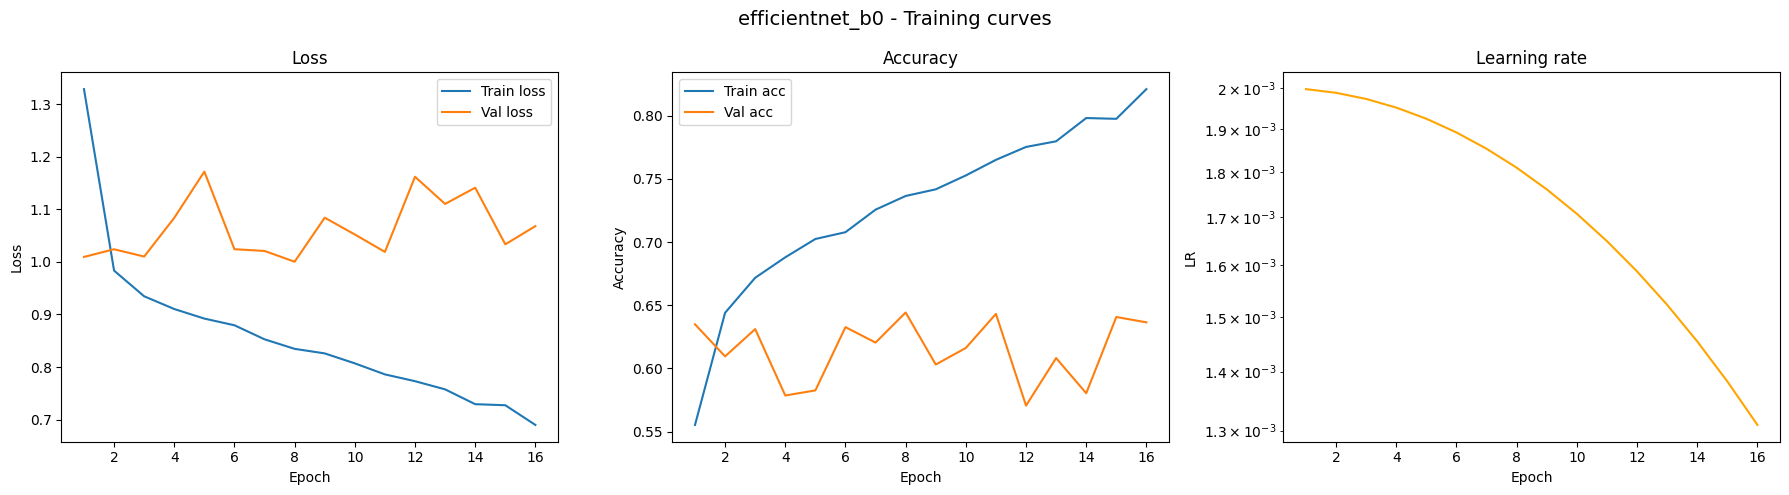

In [ ]:
epochs_ran = list(range(1, len(history["train_loss"]) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"{ARCH} - Training curves", fontsize=14)
axes[0].plot(epochs_ran, history["train_loss"], label="Train loss")
axes[0].plot(epochs_ran, history["val_loss"],   label="Val loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(epochs_ran, history["train_acc"], label="Train acc")
axes[1].plot(epochs_ran, history["val_acc"],   label="Val acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy"); axes[1].legend()
axes[2].plot(epochs_ran, history["lr"], color="orange")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR"); axes[2].set_title("Learning rate"); axes[2].set_yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"), dpi=150)
plt.show()

# **Matricea de confuzie**

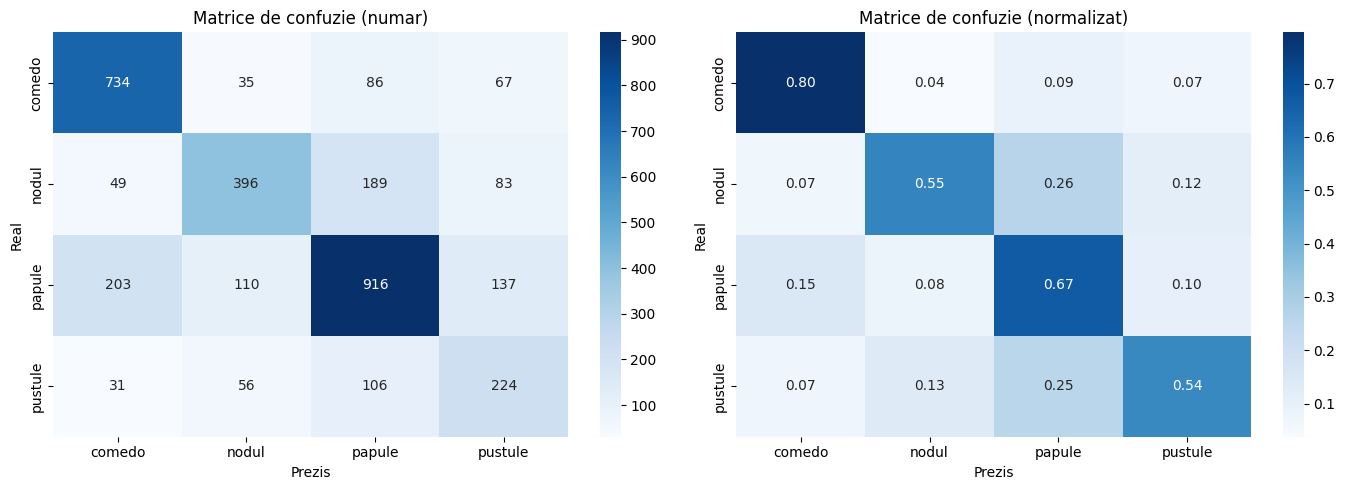

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes, ax=axes[0])
axes[0].set_title("Matrice de confuzie (numar)")
axes[0].set_ylabel("Real"); axes[0].set_xlabel("Prezis")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes, ax=axes[1])
axes[1].set_title("Matrice de confuzie (normalizat)")
axes[1].set_ylabel("Real"); axes[1].set_xlabel("Prezis")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

In [ ]:
import os
import signal

# Oprește forțat procesul principal al mediului de runtime
os.kill(os.getpid(), signal.SIGKILL)

In [ ]:
from google.colab import runtime
runtime.unassign()

In [ ]:
import os, json, time, copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
import timm

CROPS_DIR    = "/content/crops-efficientnetb0x224"

ARCH         = "efficientnet_b0"
NUM_CLASSES  = 4
IMG_SIZE     = 224
BATCH_SIZE   = 128
EPOCHS       = 40
LR           = 2e-3
LR_MIN       = 1e-6
WEIGHT_DECAY = 1e-4
PATIENCE     = 8
LABEL_SMOOTH = 0.1

SAVE_DIR = f"/content/drive/MyDrive/EfficientNetB0_acnee_b{BATCH_SIZE}_lr{LR}_alpha0.5"

CLASS_NAMES = ["comedo", "nodul", "papule", "pustule"]

Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [ ]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.15, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08)),  # ocluzie partiala
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

In [ ]:
train_dataset = datasets.ImageFolder(os.path.join(CROPS_DIR, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(CROPS_DIR, "val"),   transform=val_transform)
test_dataset  = datasets.ImageFolder(os.path.join(CROPS_DIR, "test"),  transform=val_transform)

print(f"Clase detectate de ImageFolder: {train_dataset.classes}")

ALPHA = 0.5   # sa fie ca la cls_pw = 0.5

class_counts  = Counter(train_dataset.targets)
total_samples = len(train_dataset)
class_weights = {cls: (total_samples / count) ** ALPHA
                 for cls, count in class_counts.items()}
sample_weights = [class_weights[t] for t in train_dataset.targets]
sampler = WeightedRandomSampler(weights=sample_weights,
                                num_samples=len(sample_weights),
                                replacement=True)

print("\nDistributie clase train:")
for cls_idx, cls_name in enumerate(train_dataset.classes):
    print(f"  {cls_name:12s}: {class_counts[cls_idx]:>5}  weight={class_weights[cls_idx]:.3f}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)

print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Clase detectate de ImageFolder: ['comedo', 'nodul', 'papule', 'pustule']

Distributie clase train:
  comedo      :  4904  weight=1.898
  nodul       :  3795  weight=2.158
  papule      :  6868  weight=1.604
  pustule     :  2101  weight=2.900

Train: 17668 | Val: 4495 | Test: 3422


In [ ]:
model = timm.create_model(ARCH, pretrained=True, num_classes=NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model: {ARCH}")
print(f"  Total parametri: {total_params:,}")

Model: efficientnet_b0
  Total parametri: 4,012,672


In [ ]:
# label smoothing: reduce supraincrederea, util pt clase vizual similare
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR_MIN)

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, device=device):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            preds          = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_loss    += loss.item() * images.size(0)
            total_samples += images.size(0)
    return total_loss / total_samples, total_correct / total_samples


history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
best_val_acc, best_val_loss = 0.0, float("inf")
best_weights, patience_counter = None, 0

print("=" * 65)
print(f"  Antrenare {ARCH} - {EPOCHS} epoci  |  batch={BATCH_SIZE}  |  lr={LR}")
print("=" * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion)
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    for key, val in zip(history, [train_loss, train_acc, val_loss, val_acc, current_lr]):
        history[key].append(val)

    print(f"  Ep {epoch:02d}/{EPOCHS} | "
          f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} | "
          f"lr={current_lr:.2e} | {time.time()-t0:.1f}s")

    if val_acc > best_val_acc or (val_acc == best_val_acc and val_loss < best_val_loss):
        best_val_acc, best_val_loss = val_acc, val_loss
        best_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
        torch.save({"epoch": epoch, "model_state": best_weights,
                    "val_acc": best_val_acc, "val_loss": best_val_loss,
                    "classes": train_dataset.classes, "arch": ARCH},
                   os.path.join(SAVE_DIR, "best.pth"))
        print(f"  [OK] Best model salvat (val_acc={best_val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n  Early stopping la epoca {epoch} (patience={PATIENCE})")
            break

print(f"\n  Best val_acc: {best_val_acc:.4f}")

  Antrenare efficientnet_b0 - 40 epoci  |  batch=128  |  lr=0.002
  Ep 01/40 | train_loss=1.0676 acc=0.6091 | val_loss=1.0113 acc=0.6454 | lr=2.00e-03 | 152.4s
  [OK] Best model salvat (val_acc=0.6454)
  Ep 02/40 | train_loss=0.9493 acc=0.6680 | val_loss=1.0674 acc=0.5931 | lr=1.99e-03 | 148.3s
  Ep 03/40 | train_loss=0.9392 acc=0.6726 | val_loss=1.0048 acc=0.6307 | lr=1.97e-03 | 147.9s
  Ep 04/40 | train_loss=0.9186 acc=0.6863 | val_loss=1.0233 acc=0.6260 | lr=1.95e-03 | 147.9s
  Ep 05/40 | train_loss=0.8778 acc=0.7107 | val_loss=1.0815 acc=0.6238 | lr=1.92e-03 | 146.2s
  Ep 06/40 | train_loss=0.8571 acc=0.7224 | val_loss=1.0899 acc=0.6122 | lr=1.89e-03 | 146.2s
  Ep 07/40 | train_loss=0.8483 acc=0.7256 | val_loss=0.9671 acc=0.6607 | lr=1.85e-03 | 147.3s
  [OK] Best model salvat (val_acc=0.6607)
  Ep 08/40 | train_loss=0.8340 acc=0.7344 | val_loss=1.0430 acc=0.6329 | lr=1.81e-03 | 148.9s
  Ep 09/40 | train_loss=0.8218 acc=0.7450 | val_loss=1.0638 acc=0.6178 | lr=1.76e-03 | 146.7s
  Ep

In [ ]:
model.load_state_dict(best_weights)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds, all_labels = np.array(all_preds), np.array(all_labels)

acc    = accuracy_score(all_labels, all_preds)
f1_mac = f1_score(all_labels, all_preds, average="macro")
f1_w   = f1_score(all_labels, all_preds, average="weighted")

print(f"  Accuracy      : {acc:.4f}")
print(f"  F1 macro      : {f1_mac:.4f}")
print(f"  F1 weighted   : {f1_w:.4f}")
print(f"\n  Classification report:")
print(classification_report(all_labels, all_preds,
                            target_names=test_dataset.classes, digits=4))

  Accuracy      : 0.6949
  F1 macro      : 0.6528
  F1 weighted   : 0.6876

  Classification report:
              precision    recall  f1-score   support

      comedo     0.7505    0.8059    0.7772       922
       nodul     0.6745    0.7573    0.7135       717
      papule     0.6915    0.6940    0.6927      1366
     pustule     0.5625    0.3453    0.4279       417

    accuracy                         0.6949      3422
   macro avg     0.6698    0.6506    0.6528      3422
weighted avg     0.6881    0.6949    0.6876      3422



In [ ]:
metrics = {
    "config": {"arch": ARCH, "batch_size": BATCH_SIZE, "lr": LR,
               "epochs_max": EPOCHS, "patience": PATIENCE,
               "weight_decay": WEIGHT_DECAY, "label_smoothing": LABEL_SMOOTH,
               "img_size": IMG_SIZE, "sampler": "inverse_frequency"},
    "accuracy": acc, "f1_macro": f1_mac, "f1_weighted": f1_w,
    "best_val_acc": best_val_acc,
    "classes": test_dataset.classes,
    "report": classification_report(all_labels, all_preds,
                                    target_names=train_dataset.classes,
                                    output_dict=True),
}
with open(os.path.join(SAVE_DIR, "test_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

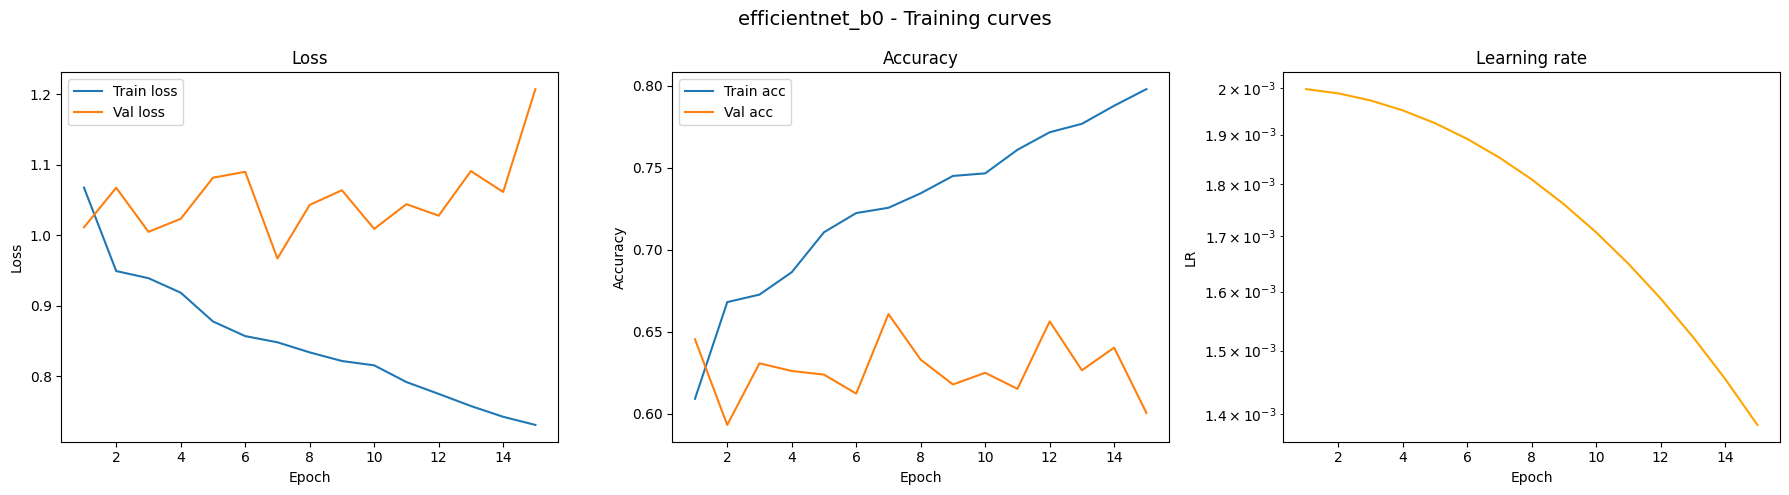

In [ ]:
epochs_ran = list(range(1, len(history["train_loss"]) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"{ARCH} - Training curves", fontsize=14)
axes[0].plot(epochs_ran, history["train_loss"], label="Train loss")
axes[0].plot(epochs_ran, history["val_loss"],   label="Val loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(epochs_ran, history["train_acc"], label="Train acc")
axes[1].plot(epochs_ran, history["val_acc"],   label="Val acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy"); axes[1].legend()
axes[2].plot(epochs_ran, history["lr"], color="orange")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR"); axes[2].set_title("Learning rate"); axes[2].set_yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"), dpi=150)
plt.show()

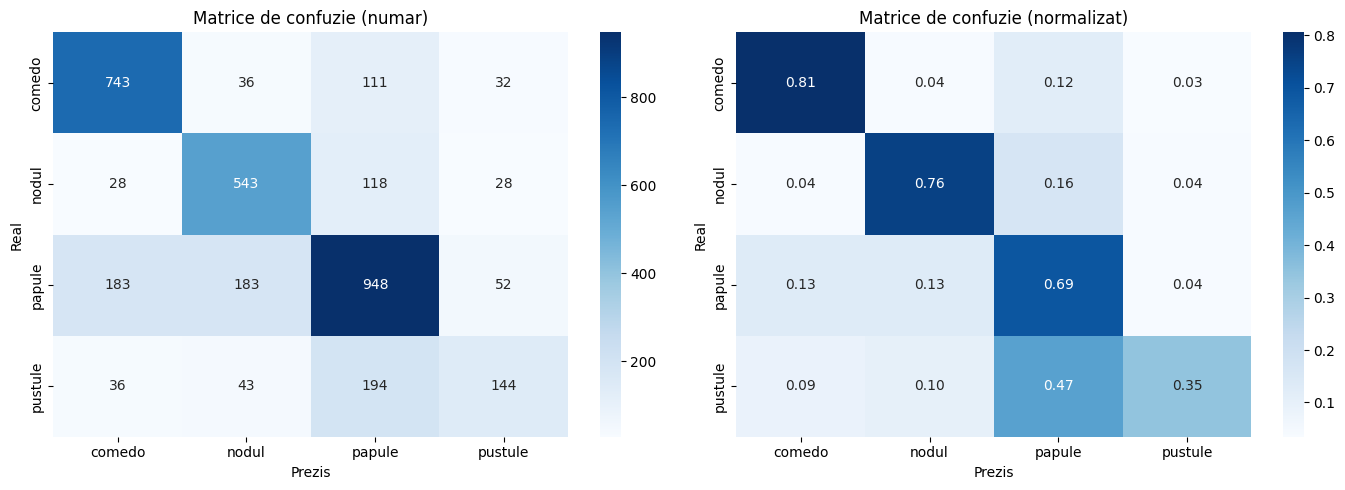

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes, ax=axes[0])
axes[0].set_title("Matrice de confuzie (numar)")
axes[0].set_ylabel("Real"); axes[0].set_xlabel("Prezis")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes, ax=axes[1])
axes[1].set_title("Matrice de confuzie (normalizat)")
axes[1].set_ylabel("Real"); axes[1].set_xlabel("Prezis")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

In [ ]:
# F1 macro pe VALIDARE pentru ambele checkpoint-uri
from sklearn.metrics import f1_score

for name, path in [("alpha=1.0", "/content/drive/MyDrive/EfficientNetB0_acnee/best.pth"),
                   ("alpha=0.5", "/content/drive/MyDrive/EfficientNetB0_acnee_b128_lr0.002_alpha0.5/best.pth")]:
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state"]); model.eval()
    preds, labels_all = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            preds.extend(model(images.to(device)).argmax(1).cpu().numpy())
            labels_all.extend(labels.numpy())
    print(f"{name}: val_acc={ckpt['val_acc']:.4f}  "
          f"val_F1_macro={f1_score(labels_all, preds, average='macro'):.4f}")

alpha=1.0: val_acc=0.6487  val_F1_macro=0.6112
alpha=0.5: val_acc=0.6607  val_F1_macro=0.6193
